In [3]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
import matplotlib.pyplot as plt
import timeit

STUDENT_SEED = 421944 
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32

np.random.seed(STUDENT_SEED)
tf.random.set_seed(STUDENT_SEED)

print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Loading in the data

- `image_dataset_from_directory` Loads the images in batches from disk rather than everything into memory at once

In [4]:
train_ds = keras.utils.image_dataset_from_directory(
    "./food",
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="training"
)

print(train_ds)

remaining_ds = keras.utils.image_dataset_from_directory(
    "./food",
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="validation"
)

print(remaining_ds)

remaining_batches = tf.data.experimental.cardinality(remaining_ds).numpy()
val_batches = int(remaining_batches * 0.33)
test_batches = remaining_batches - val_batches

val_ds = remaining_ds.take(val_batches)
test_ds = remaining_ds.skip(val_batches)

Found 19000 files belonging to 19 classes.
Using 13300 files for training.


I0000 00:00:1777903591.101388   23832 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5241 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060, pci bus id: 0000:01:00.0, compute capability: 8.9


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>
Found 19000 files belonging to 19 classes.
Using 5700 files for validation.
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [5]:
class_names = train_ds.class_names
print(class_names)

num_classes = len(class_names)
print(f"Number of classes: {num_classes}")

['carrot_cake', 'cheesecake', 'chicken_wings', 'chocolate_cake', 'donuts', 'fish_and_chips', 'french_fries', 'fried_rice', 'garlic_bread', 'hamburger', 'hot_dog', 'nachos', 'onion_rings', 'pancakes', 'pizza', 'red_velvet_cake', 'spaghetti_bolognese', 'steak', 'waffles']
Number of classes: 19


## Normalisation

Since every pixel in the image is stored as a number from 0 to 255 where like 0 is compelely dark, then 255 is full brightness, white in greyscale or full RGB. So normalising the data will map it between 0.0 and 1.0.

Doing this doesnt actually change how the image works, but it does help for weight initialisations. So later on when training starts, the weights are initialised as smaller random numbers, but if the inputs are like 0-255, the initial dot products are enourmous, which isnt good. It also works best when using the Gradient Descent optimiser ADAM

In [6]:
normalisation_layer = keras.layers.Rescaling(1./255)

## Class Imbalance

So this occurs when some categories have more images than others. For example, if Pizza has 2000 images but sushi has 200, the model will acheive 90% accuracy by just predicing pizza, making it useless for other classes.

### Checking for class distribution

First we can check for the distribution for each image type, since the folders are named after the food they contain, it makes it easier to plot them on a bar chart, the results show that for each food type, there is 1000 images, so there is equal class distribution.

```
carrot_cake: 1000
cheesecake: 1000
chicken_wings: 1000
chocolate_cake: 1000
donuts: 1000
fish_and_chips: 1000
french_fries: 1000
fried_rice: 1000
garlic_bread: 1000
hamburger: 1000
hot_dog: 1000
nachos: 1000
onion_rings: 1000
pancakes: 1000
pizza: 1000
red_velvet_cake: 1000
spaghetti_bolognese: 1000
steak: 1000
waffles: 1000
```

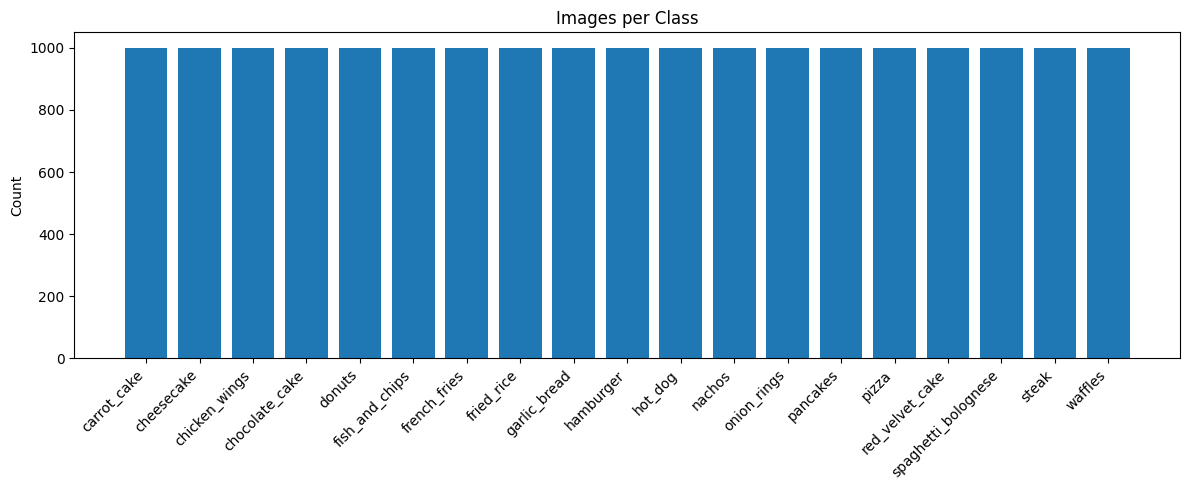

carrot_cake: 1000
cheesecake: 1000
chicken_wings: 1000
chocolate_cake: 1000
donuts: 1000
fish_and_chips: 1000
french_fries: 1000
fried_rice: 1000
garlic_bread: 1000
hamburger: 1000
hot_dog: 1000
nachos: 1000
onion_rings: 1000
pancakes: 1000
pizza: 1000
red_velvet_cake: 1000
spaghetti_bolognese: 1000
steak: 1000
waffles: 1000


In [7]:
import os
import matplotlib.pyplot as plt

data_dir = './food/'
class_counts = {}

for class_name in sorted(os.listdir(data_dir)):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        class_counts[class_name] = count

# Plot it
plt.figure(figsize=(12, 5))
plt.bar(class_counts.keys(), class_counts.values())
plt.xticks(rotation=45, ha='right')
plt.title('Images per Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

for name, count in class_counts.items():
    print(f"{name}: {count}")

### Imbalanced Classes

Although the images provided in the food dataset is perfectly balanced at 1000 images, this isnt always the case. Many real world datasets would have variation in the number of images, which will create an imbalance.

In this way, the model learns to favour majority classes, where teh accuracy looks high but minority class performance is terrible. Introducing class weights will allow each class to be treated fairly.

In [8]:
import numpy as np

total_images = sum(class_counts.values())
num_classes = len(class_counts)

class_weights = {}
for i, class_name in enumerate(sorted(class_counts.keys())):
    count = class_counts[class_name]
    # Classes with fewer images get higher weight
    weight = total_images / (num_classes * count)
    class_weights[i] = weight

print(class_weights)

{0: 1.0, 1: 1.0, 2: 1.0, 3: 1.0, 4: 1.0, 5: 1.0, 6: 1.0, 7: 1.0, 8: 1.0, 9: 1.0, 10: 1.0, 11: 1.0, 12: 1.0, 13: 1.0, 14: 1.0, 15: 1.0, 16: 1.0, 17: 1.0, 18: 1.0}


## Exploratory Data Analysis

Number of classes: 19
Number of images: 19000
Image size: 128×128
Colour mode: RGB (3 channels)
Train: 13312 images
Val:   1888 images
Test:  3840 images


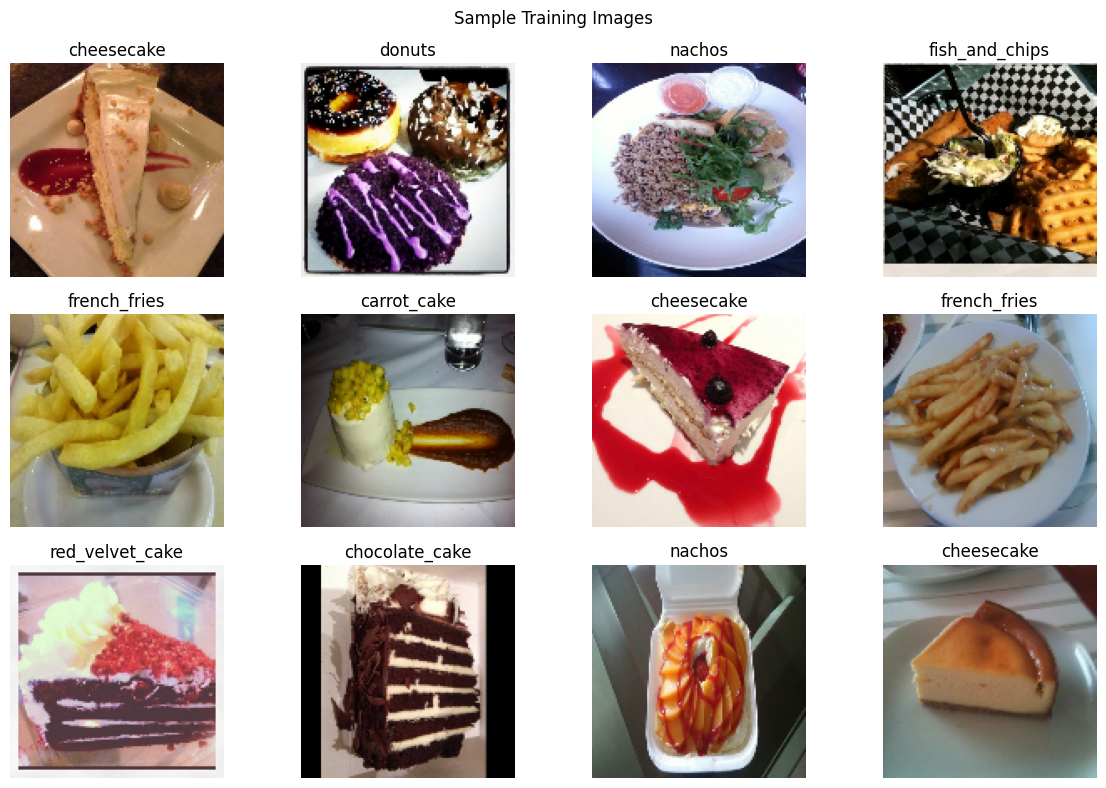

In [9]:
import matplotlib.pyplot as plt
import tensorflow as tf

print(f"Number of classes: {len(class_counts)}")
print(f"Number of images: {total_images}")

for images, labels in train_ds.take(1):
    h, w, c = images[0].shape
    print(f"Image size: {h}×{w}")
    print(f"Colour mode: {'RGB' if c == 3 else 'Greyscale'} ({c} channel{'s' if c > 1 else ''})")



BATCH_SIZE = 32

train_count = tf.data.experimental.cardinality(train_ds).numpy() * BATCH_SIZE
val_count   = tf.data.experimental.cardinality(val_ds).numpy()   * BATCH_SIZE
test_count  = tf.data.experimental.cardinality(test_ds).numpy()  * BATCH_SIZE

print(f"Train: {train_count} images")
print(f"Val:   {val_count} images")
print(f"Test:  {test_count} images")


plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1): 
    for i in range(min(12, len(images))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()

## Building the CNN Model

### Output

`nv2d_2 (Conv2D) → (None, 128, 128, 32) — 896 params` - 32 filters slide across the image looking for patterns. Output is still 128x128 ecause of `padding=same`. Now there is 32 versions of the image, each highlighting a different pattern (Edges, colours, etc)
- `32 filters × (3×3 kernel × 3 input channels + 1 bias) = 32 × 28 = 896`

`max_pooling2d_2 → (None, 64, 64, 32) — 0 params` - Halves the spatial size 128 - 64. Takes the maximum value in each 2x2 window

`conv2d_3 (Conv2D) → (None, 64, 64, 64) — 18,496 params` - 64 filters now, looking for more complex patterns. Input has 32 channels (From previous layer), so each filter is 3x3x32
- `64 × (3×3×32 + 1) = 64 × 289 = 18,496`

`max_pooling2d_3 → (None, 32, 32, 64) — 0 params` - Another halving. Halves again: 64→32. You now have 32×32×64 = 65,536 values.

`flatten_1 → (None, 65536) — 0 params` Reshapes the 32x32x64 block into a flat list of 65,536 values. 

`dense_2 (Dense) → (None, 128) — 8,388,736 params` - Every one of those 65k values connects to every one of the 128 neurons. This is why this layer dominates the parameter count `8,388,736 = 65,536 × 128 + 128 = 8,388,736`

`dense_3 (Dense) → (None, 19) — 2,451 params` - The output layer where 19 neurons = 19 food classes in the dataset. Softmax converts these to probabilities that sum to 1. The highest one is the models prediction

In [10]:
NUM_CLASSES = 19

def build_baseline_cnn(input_shape, num_classes):
    model = keras.Sequential([
        # PREPROCESSING
        layers.Rescaling(1./255, input_shape=input_shape),

        # BLOCK 1
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # BLOCK 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CLASSIFIER
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])

    return model

model = build_baseline_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)
model.summary()

/home/michael/miniconda3/envs/ml_assignment/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,388,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 19)             │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,410,579 (32.08 MB)

 Trainable params: 8,410,579 (32.08 MB)

 Non-trainable params: 0 (0.00 B)

## Compiling the model

- `loss='sparse_categorical_crossentropy',` labels are ints like 0,1,2,3 etc

In [11]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## Training the model (overfitting)

So based on the data results produced and graphed below, we will notice that over the course of the 20 epochs that the training loss decreases while the validation loss increases. As well the training accurracy increases and the val stops around 2.2 accuracy.

This is a clear sign of overfitting, as the training loss decreases while validation increases in loss. The model is failing to learn general patterns, but instead memorising the training images!

To combat this, will add a dropout to the neural network, and augment the data such as rotating images etc

In [12]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

Epoch 1/20


I0000 00:00:1777903594.664888   24120 service.cc:153] XLA service 0x7efe74033710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777903594.664929   24120 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4060, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777903594.711741   24120 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777903594.868412   24120 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777903594.874959   24120 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1772__.30
I0000 00:00:1777903595.367643   24120 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


  5/416 ━━━━━━━━━━━━━━━━━━━━ 12s 31ms/step - accuracy: 0.0195 - loss: 4.2483  

I0000 00:00:1777903600.645692   24120 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


415/416 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.1054 - loss: 2.9117

I0000 00:00:1777903607.530196   24122 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1772__.30
I0000 00:00:1777903607.699311   24122 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 33ms/step - accuracy: 0.1456 - loss: 2.7200 - val_accuracy: 0.1801 - val_loss: 2.5723
Epoch 2/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.2747 - loss: 2.3297 - val_accuracy: 0.2617 - val_loss: 2.4254
Epoch 3/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.4703 - loss: 1.7297 - val_accuracy: 0.2537 - val_loss: 2.6638
Epoch 4/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7092 - loss: 0.9600 - val_accuracy: 0.2431 - val_loss: 3.2835
Epoch 5/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8743 - loss: 0.4409 - val_accuracy: 0.2484 - val_loss: 4.3728
Epoch 6/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9421 - loss: 0.2077 - val_accuracy: 0.2426 - val_loss: 5.2622
Epoch 7/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9646 - loss: 0.1317 - val_accuracy: 0.2452 - val_loss: 5.5570
Epoch 8/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9779 - loss: 0.0848 - val_accuracy: 0.24

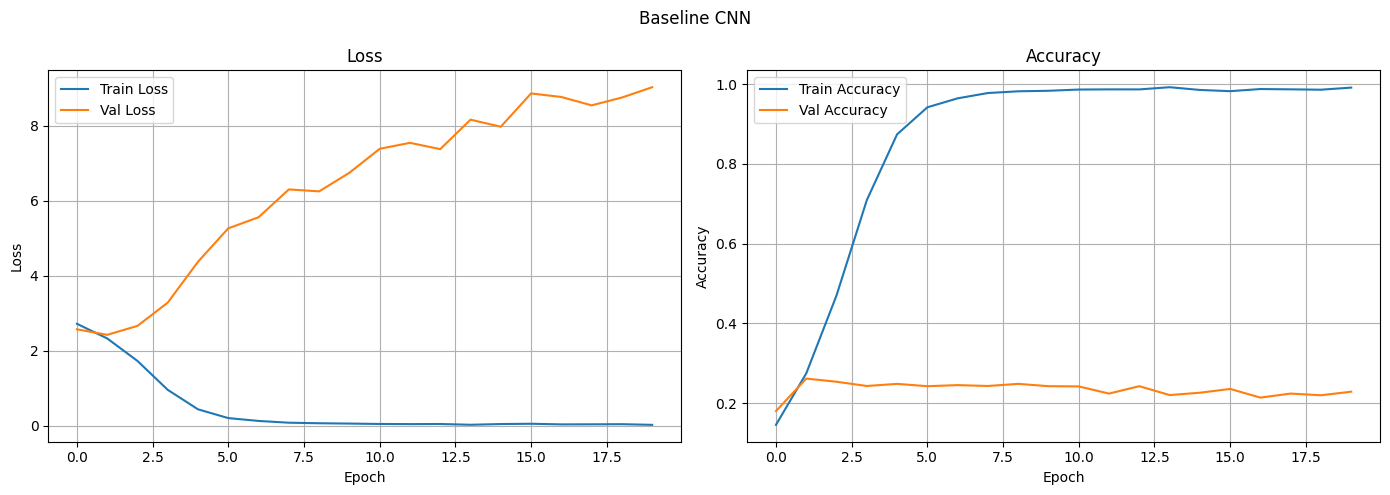

In [13]:
import matplotlib.pyplot as plt

def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss curves
    ax1.plot(history.history['loss'], label='Train Loss')
    ax1.plot(history.history['val_loss'], label='Val Loss')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True)
    
    # Accuracy curves
    ax2.plot(history.history['accuracy'], label='Train Accuracy')
    ax2.plot(history.history['val_accuracy'], label='Val Accuracy')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True)
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

plot_history(history, title='Baseline CNN')

## Building more deeper CNN (Underfitting)

This is a case now where the model is underfitting on the data,

In [67]:
NUM_CLASSES = 19

def build_deeper_cnn(input_shape, num_classes, dropout=0.5):
    model = keras.Sequential([
        # PREPROCESSING
        layers.Rescaling(1./255, input_shape=input_shape),

        # BLOCK 1
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # BLOCK 2
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # BLOCK 3
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
        layers.MaxPooling2D((2, 2)),

        # CLASSIFIER
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(dropout),
        layers.Dense(num_classes, activation="softmax"),
    ])

    return model

model = build_deeper_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES, dropout=0.5)
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

/home/michael/miniconda3/envs/ml_assignment/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_18 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_76 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_77 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_78 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_79 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_80 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_81 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_48 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,680,755 (33.11 MB)

 Trainable params: 8,680,755 (33.11 MB)

...

Epoch 1/20


I0000 00:00:1777912054.901548   24121 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_571621__.43


414/416 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.0503 - loss: 2.9491

I0000 00:00:1777912072.322801   24120 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_571621__.43


416/416 ━━━━━━━━━━━━━━━━━━━━ 24s 46ms/step - accuracy: 0.0491 - loss: 2.9457 - val_accuracy: 0.0461 - val_loss: 2.9447
Epoch 2/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.0530 - loss: 2.9447 - val_accuracy: 0.0456 - val_loss: 2.9450
Epoch 3/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.0500 - loss: 2.9447 - val_accuracy: 0.0561 - val_loss: 2.9451
Epoch 4/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.0504 - loss: 2.9448 - val_accuracy: 0.0561 - val_loss: 2.9449
Epoch 5/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.0510 - loss: 2.9446 - val_accuracy: 0.0567 - val_loss: 2.9449
Epoch 6/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 0.0521 - loss: 2.9447 - val_accuracy: 0.0466 - val_loss: 2.9452
Epoch 7/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.0520 - loss: 2.9447 - val_accuracy: 0.0535 - val_loss: 2.9452
Epoch 8/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 14s 35ms/step - accuracy: 0.0525 - loss: 2.9446 - val_accurac

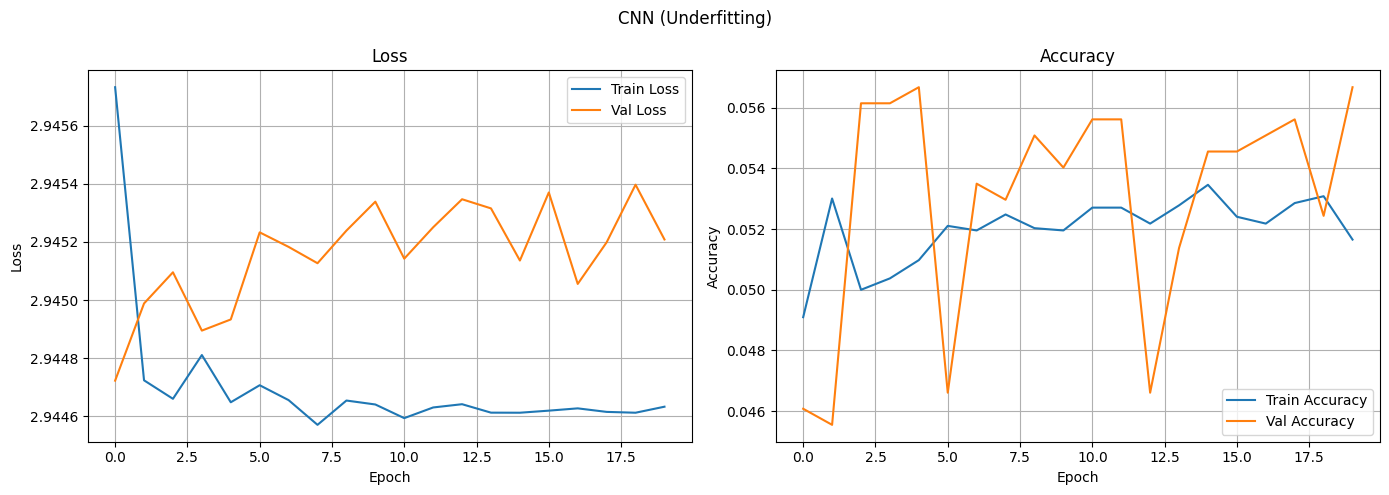

In [68]:
plot_history(history, title='CNN (Underfitting)')

## Batch stuff (Overfitting)

The model is failing to recognise general patterns, it is successfully learning to recognise food but failing when given unseen data like in our validation.

In [71]:
# Check how many folders are in your 'train' directory to be 100% sure!
NUM_CLASSES = 19 

def build_food_cnn(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(), # Keeps the math stable
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(), # Reduces parameter explosion
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

model = build_food_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)
model.summary()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

Model: "sequential_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_21 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_86 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_53 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_87 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_54 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,299 (161.32 KB)

 Trainable params: 41,107 (160.57 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/20


I0000 00:00:1777912585.994297   24120 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_629900__.43


415/416 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.1153 - loss: 2.8278

I0000 00:00:1777912595.922510   24115 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_629900__.43


KeyboardInterrupt: 

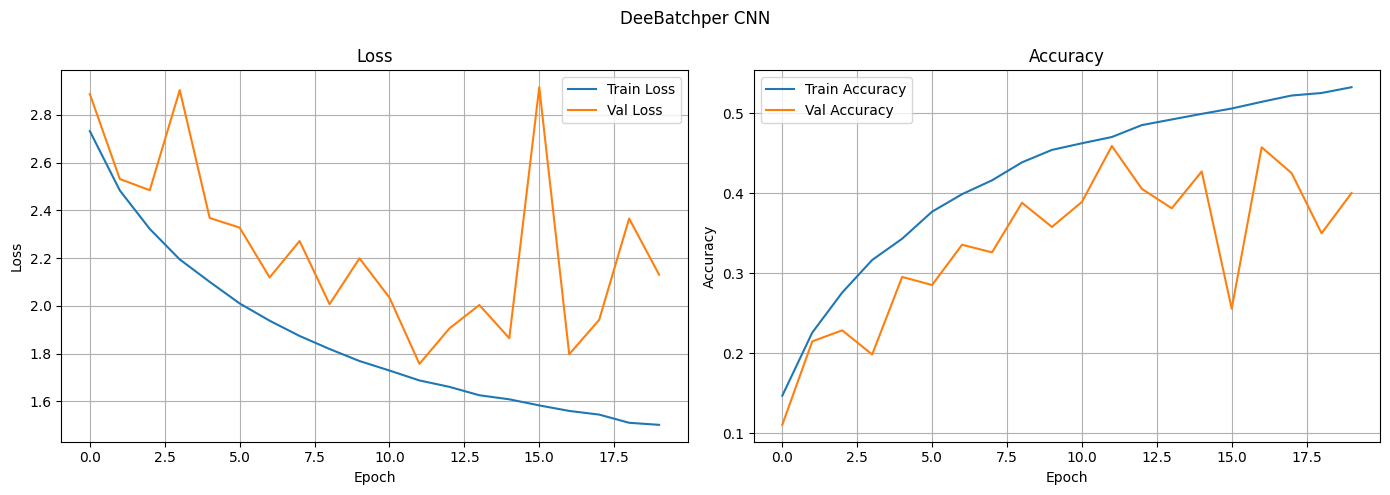

In [65]:
plot_history(history, title='DeeBatchper CNN')

## Good stable

Both training accuracy and validatio accuracy increasing together.

Added 

```
layers.RandomFlip('horizontal'),
layers.RandomRotation(0.1),
layers.RandomZoom(0.1),
```

and made epochs 40

"Adding rotation and zoom augmentation improved the stability of the training loss but introduced significant volatility in the validation metrics. The final validation accuracy of 38% suggests that while the model is learning general features, it remains sensitive to extreme image transformations."

In [91]:
# Check how many folders are in your 'train' directory to be 100% sure!
NUM_CLASSES = 19 

def build_food_cnn_stable(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(), # Keeps the math stable
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.GlobalAveragePooling2D(), # Reduces parameter explosion
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

m = build_food_cnn_stable(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)
m.summary()

m.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

EPOCHS = 40

his = m.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weights
)

Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_18 (RandomFlip)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_15              │ (None, 128, 128, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_15 (RandomZoom)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_34 (Rescaling)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_115 (Conv2D)             │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_47          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_82 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_116 (Conv2D)             │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_48          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_83 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_13     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_60 (Dense)                │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_61 (Dense)                │ (None, 19)             │         4,883 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,299 (161.32 KB)

 Trainable params: 41,107 (160.57 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.1430 - loss: 2.7485 - val_accuracy: 0.0906 - val_loss: 2.9169
Epoch 2/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.2148 - loss: 2.5363 - val_accuracy: 0.2267 - val_loss: 2.5081
Epoch 3/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.2530 - loss: 2.4040 - val_accuracy: 0.2272 - val_loss: 2.4921
Epoch 4/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.2877 - loss: 2.2922 - val_accuracy: 0.2092 - val_loss: 2.8706
Epoch 5/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.3160 - loss: 2.2180 - val_accuracy: 0.2500 - val_loss: 2.4832
Epoch 6/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.3320 - loss: 2.1435 - val_accuracy: 0.2733 - val_loss: 2.4527
Epoch 7/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.3515 - loss: 2.0848 - val_accuracy: 0.3003 - val_loss: 2.2821
Epoch 8/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 13s 31ms/step - accuracy: 0.3698 - loss: 2.0373 - 

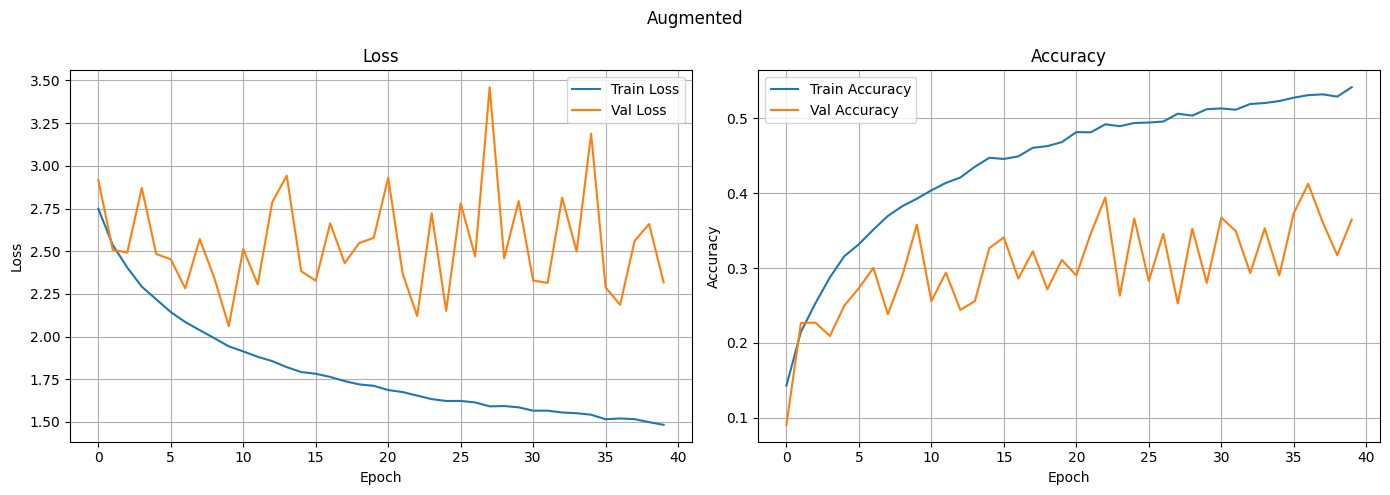

In [92]:
plot_history(his, title='Augmented')

Epoch 1/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.1650 - loss: 2.7354 - val_accuracy: 0.1356 - val_loss: 2.9996
Epoch 2/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 17s 40ms/step - accuracy: 0.2462 - loss: 2.4383 - val_accuracy: 0.2278 - val_loss: 2.5043
Epoch 3/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.3074 - loss: 2.2237 - val_accuracy: 0.2738 - val_loss: 2.2731
Epoch 4/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.3686 - loss: 2.0405 - val_accuracy: 0.2066 - val_loss: 2.9387
Epoch 5/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.4181 - loss: 1.8887 - val_accuracy: 0.2924 - val_loss: 2.3619
Epoch 6/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.4616 - loss: 1.7380 - val_accuracy: 0.2823 - val_loss: 2.5886
Epoch 7/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.5077 - loss: 1.5955 - val_accuracy: 0.3162 - val_loss: 2.2573
Epoch 8/40
416/416 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.5372 - loss: 1.5107 - 

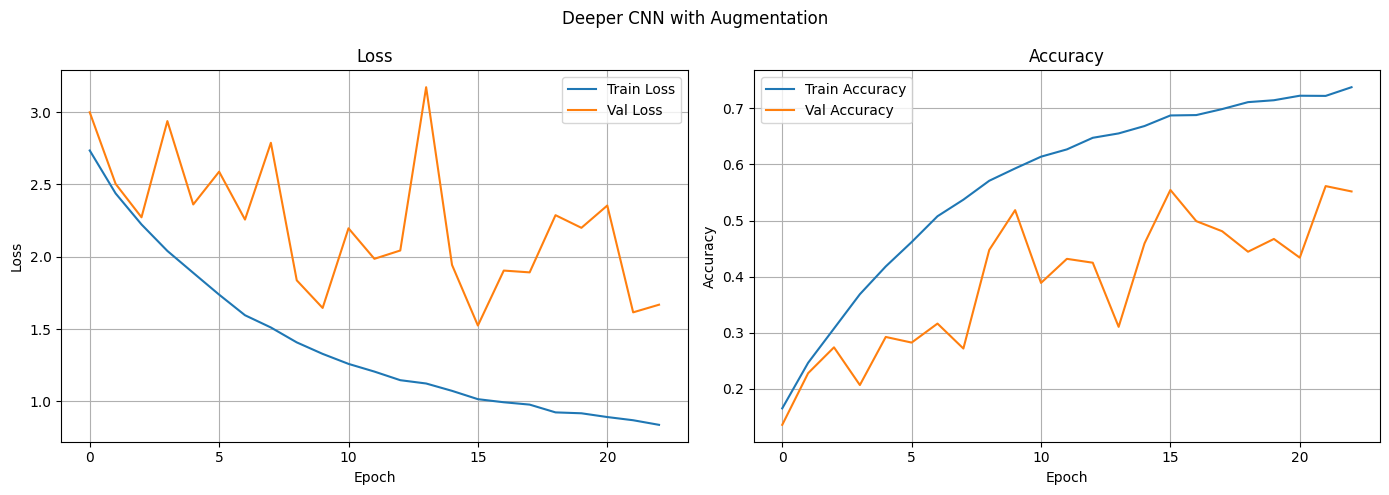

In [90]:
def build_food_cnn_v3(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),


        layers.GlobalAveragePooling2D(),
        layers.Dense(512, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

m3 = build_food_cnn_v3(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)

m3.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callback = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,        # increased — val is noisy so give it more room
    restore_best_weights=True
)

history_v3 = m3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=40,
    class_weight=class_weights,
    callbacks=[callback]
)

plot_history(history_v3, title='Deeper CNN with Augmentation')


Epoch 1/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 24s 50ms/step - accuracy: 0.1678 - loss: 2.9196 - val_accuracy: 0.1165 - val_loss: 2.9708
Epoch 2/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.2570 - loss: 2.4190 - val_accuracy: 0.1409 - val_loss: 2.7776
Epoch 3/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 49ms/step - accuracy: 0.3158 - loss: 2.2266 - val_accuracy: 0.2728 - val_loss: 2.4197
Epoch 4/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.3753 - loss: 2.0501 - val_accuracy: 0.1472 - val_loss: 3.4779
Epoch 5/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.4234 - loss: 1.9116 - val_accuracy: 0.3083 - val_loss: 2.4898
Epoch 6/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.4514 - loss: 1.8137 - val_accuracy: 0.3739 - val_loss: 2.1399
Epoch 7/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.4932 - loss: 1.6676 - val_accuracy: 0.3141 - val_loss: 2.5145
Epoch 8/50
416/416 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - accuracy: 0.5293 - loss: 1.5605 - 

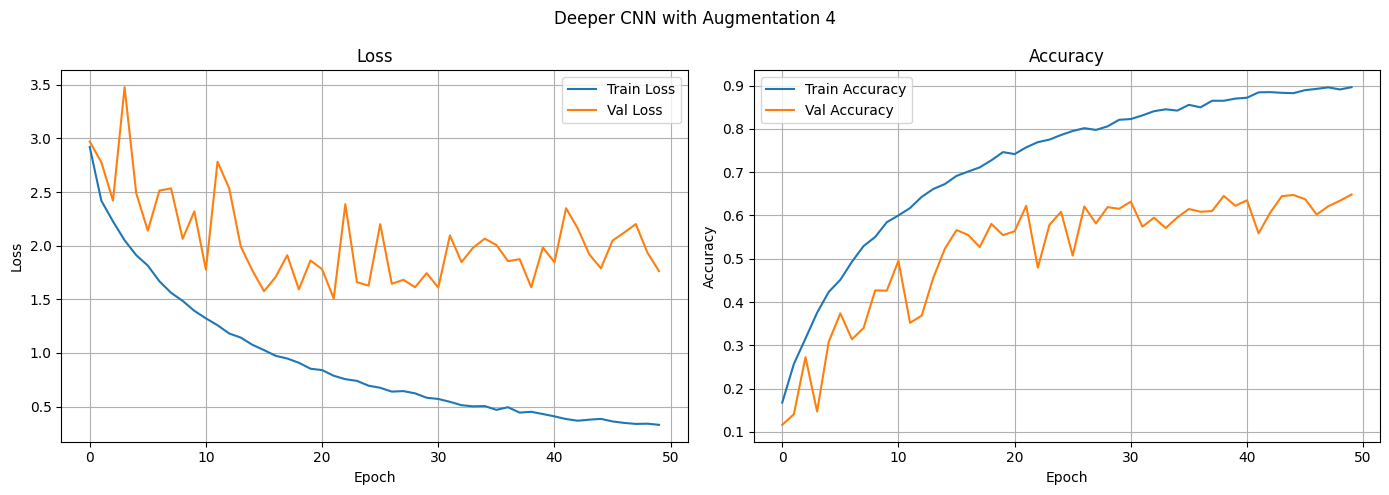

In [94]:
def build_food_cnn_v4(input_shape, num_classes):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.RandomFlip('horizontal'),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(512, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(1024, (3,3), activation="relu", padding="same"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),


        layers.GlobalAveragePooling2D(),
        layers.Dense(2048, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation="softmax")
    ])
    return model

m4 = build_food_cnn_v4(input_shape=(128, 128, 3), num_classes=NUM_CLASSES)

m4.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_v4 = m4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights
)

plot_history(history_v4, title='Deeper CNN with Augmentation 4')


# Transfer Learning

In [108]:
IMAGE_SIZE_TL = (128, 128)

train_ds_tl = keras.utils.image_dataset_from_directory(
    "./food",
    image_size=IMAGE_SIZE_TL,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="training"
)

remaining_ds_tl = keras.utils.image_dataset_from_directory(
    "./food",
    image_size=IMAGE_SIZE_TL,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=STUDENT_SEED,
    validation_split=0.3,
    subset="validation"
)

remaining_batches = tf.data.experimental.cardinality(remaining_ds_tl).numpy()
val_batches = int(remaining_batches * 0.33)

val_ds_tl = remaining_ds_tl.take(val_batches)
test_ds_tl = remaining_ds_tl.skip(val_batches)


Found 19000 files belonging to 19 classes.
Using 13300 files for training.
Found 19000 files belonging to 19 classes.
Using 5700 files for validation.


In [109]:
import keras
from keras import layers
from keras.applications import MobileNetV2  # or VGG16, ResNet50

IMAGE_SIZE = (128, 128)  # match what the base model was trained on

# Step 1: Load the pre-trained base model
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,     # don't include the original ImageNet classifier
    weights='imagenet'     # use weights pre-trained on ImageNet
)

# Step 2: Freeze the base model — don't update its weights
base_model.trainable = False

print(f"Base model parameters: {base_model.count_params():,}")
print(f"Trainable: {sum([tf.size(v).numpy() for v in base_model.trainable_variables])}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Base model parameters: 2,257,984
Trainable: 0


In [110]:
# Step 3: Add preprocessing specific to the base model
# Each model has its own expected input range — use the built-in preprocessor
from keras.applications.mobilenet_v2 import preprocess_input  # use the right one for your model
# For VGG16: from keras.applications.vgg16 import preprocess_input
# For ResNet50: from keras.applications.resnet50 import preprocess_input

# Step 4: Build the full model
def build_transfer_model(base_model, num_classes):
    inputs = keras.Input(shape=(128, 128, 3))
    
    # Preprocessing: scale to the expected range for this model
    x = preprocess_input(inputs)   # MobileNetV2 expects [-1, 1], ResNet/VGG expect different ranges
    
    # Base model (frozen)
    x = base_model(x, training=False)  # training=False keeps BatchNorm in inference mode
    
    # Our new classifier head
    x = layers.GlobalAveragePooling2D()(x)   # convert spatial features to a vector
    x = layers.Dropout(0.3)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    
    model = keras.Model(inputs, outputs)
    return model

model_tl = build_transfer_model(base_model, NUM_CLASSES)
model_tl.summary()

Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_44 (InputLayer)     │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_5 (TrueDivide)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_5 (Subtract)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_21     │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_39 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_77 (Dense)                │ (None, 19)             │         2,451 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,424,403 (9.25 MB)

 Trainable params: 166,419 (650.07 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Phase 1

In [111]:
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),  # normal learning rate for the new head
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

import time
start = time.time()
history_tl = model_tl.fit(
    train_ds_tl,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stopping],
    class_weight=class_weights
)
training_time_tl = time.time() - start

Epoch 1/20


I0000 00:00:1777931713.886727   24120 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1250600__.120
E0000 00:00:1777931717.629824   24120 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


413/416 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3937 - loss: 2.0627

I0000 00:00:1777931730.315216   24122 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1250600__.120
E0000 00:00:1777931734.083163   24122 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


416/416 ━━━━━━━━━━━━━━━━━━━━ 36s 48ms/step - accuracy: 0.5238 - loss: 1.5875 - val_accuracy: 0.6912 - val_loss: 1.0039
Epoch 2/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.6674 - loss: 1.0822 - val_accuracy: 0.6965 - val_loss: 0.9783
Epoch 3/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7032 - loss: 0.9559 - val_accuracy: 0.7150 - val_loss: 0.9294
Epoch 4/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7268 - loss: 0.8720 - val_accuracy: 0.7172 - val_loss: 0.9114
Epoch 5/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7383 - loss: 0.8172 - val_accuracy: 0.7097 - val_loss: 0.9665
Epoch 6/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.7547 - loss: 0.7750 - val_accuracy: 0.7219 - val_loss: 0.9130
Epoch 7/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7617 - loss: 0.7447 - val_accuracy: 0.7140 - val_loss: 0.9229
Epoch 8/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7729 - loss: 0.7079 - val_accuracy: 0.71

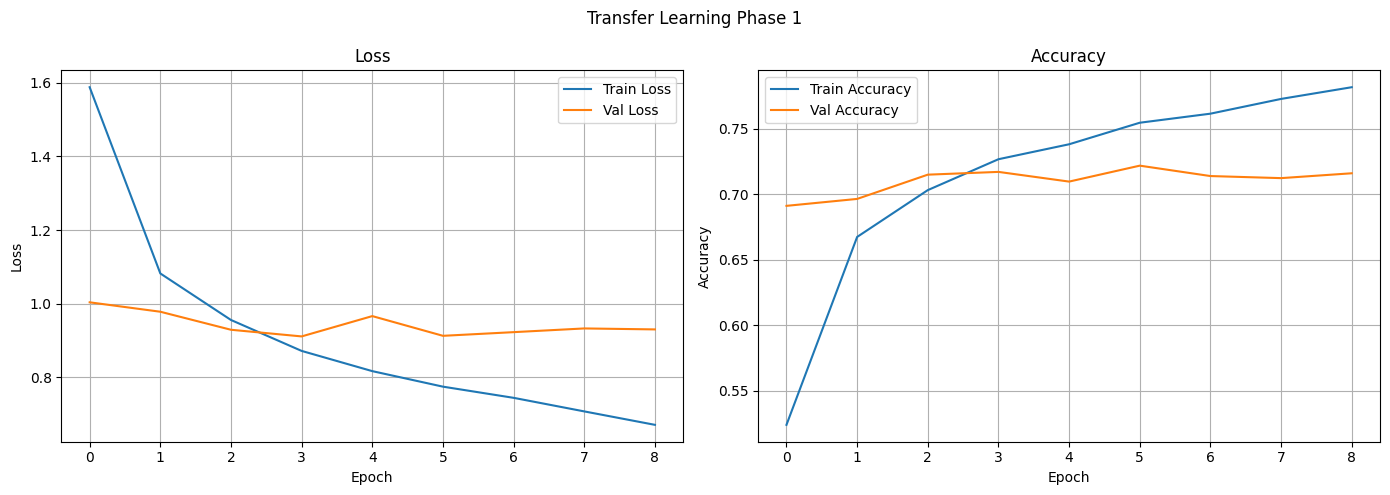

In [113]:
plot_history(history_tl, title='Transfer Learning Phase 1')

## Phase 2 - Fine Tuning

In [119]:
# Step 1: Unfreeze the top layers of the base model
base_model.trainable = True  # unfreeze everything

# Find out how many layers the base model has
print(f"Total layers in base model: {len(base_model.layers)}")

# Freeze all layers except the last N
fine_tune_from = len(base_model.layers) - 20  # unfreeze the top 20 layers

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False  # keep early layers frozen

# Check how many layers are now trainable
trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable layers: {trainable_count} / {len(base_model.layers)}")

Total layers in base model: 154
Trainable layers: 20 / 154


In [123]:
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # 100x smaller than before
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Step 3: Train for at least 1 epoch (assignment requirement)
start = time.time()
history_ft = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,  # fine-tuning usually needs fewer epochs
    callbacks=[early_stopping],
    class_weight=class_weights
)
ft_time = time.time() - start

Epoch 1/20


I0000 00:00:1777932181.957952   24113 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1316733__.148


411/416 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8033 - loss: 0.6294

I0000 00:00:1777932192.419993   24119 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_1316733__.148


416/416 ━━━━━━━━━━━━━━━━━━━━ 24s 34ms/step - accuracy: 0.8000 - loss: 0.6316 - val_accuracy: 0.7426 - val_loss: 0.8608
Epoch 2/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8056 - loss: 0.6038 - val_accuracy: 0.7431 - val_loss: 0.8493
Epoch 3/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8170 - loss: 0.5786 - val_accuracy: 0.7479 - val_loss: 0.8491
Epoch 4/20
416/416 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.8182 - loss: 0.5662 - val_accuracy: 0.7484 - val_loss: 0.8380
Epoch 5/20
146/416 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.8217 - loss: 0.5562

KeyboardInterrupt: 

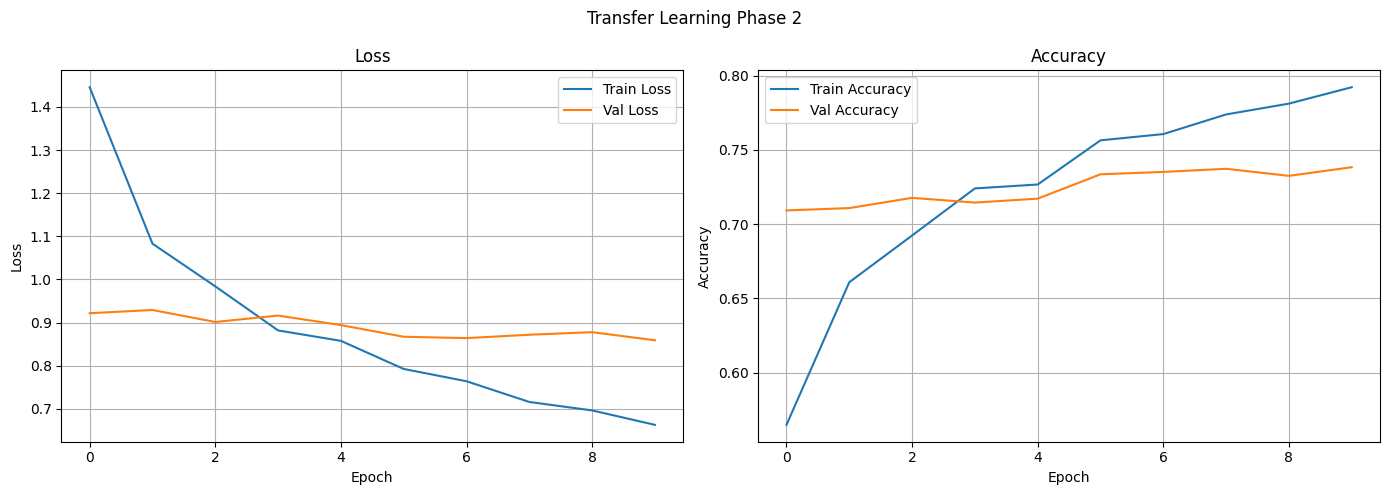

In [121]:
plot_history(history_ft, title='Transfer Learning Phase 2')

Phase 1 - Best val accuracy: 0.7219279408454895
Phase 2 - Best val accuracy: 0.7383474707603455


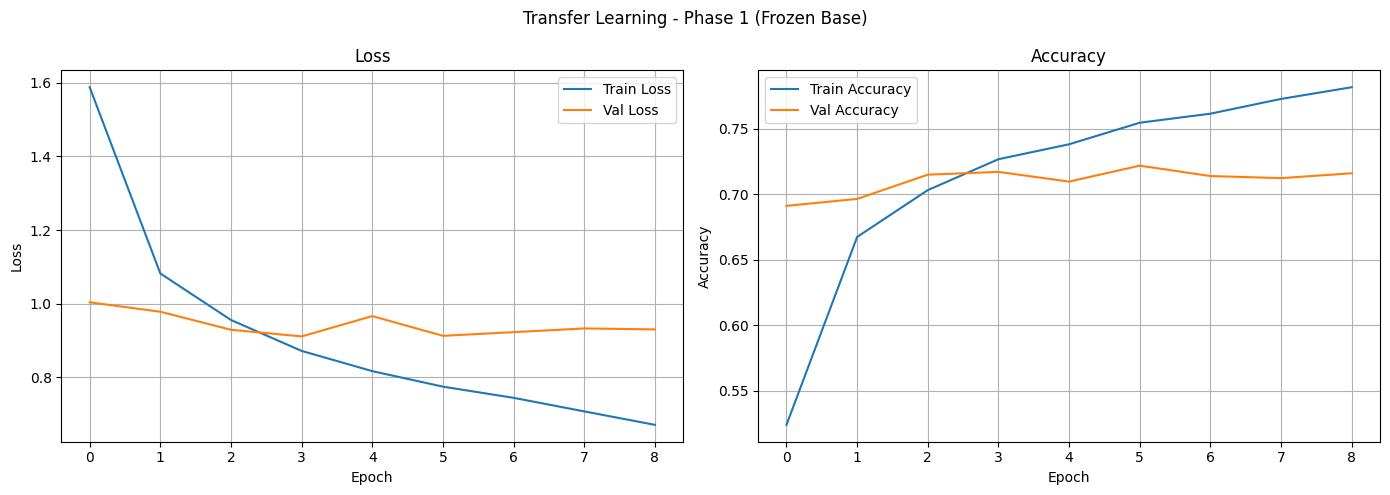

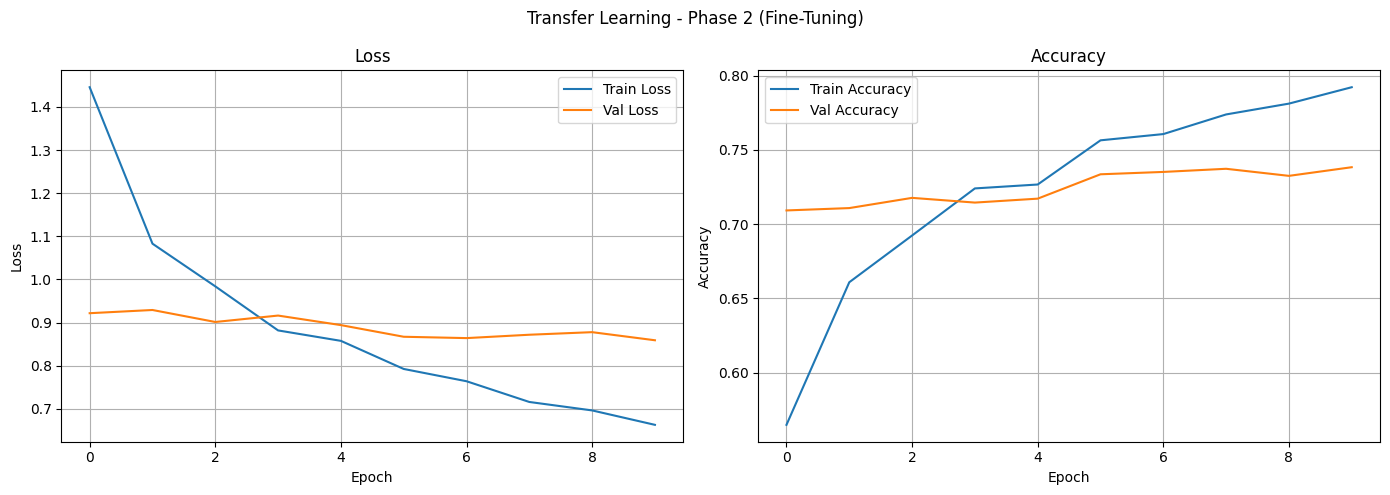

In [133]:
print("Phase 1 - Best val accuracy:", max(history_tl.history['val_accuracy']))
print("Phase 2 - Best val accuracy:", max(history_ft.history['val_accuracy']))

# Plot both histories
plot_history(history_tl, "Transfer Learning - Phase 1 (Frozen Base)")
plot_history(history_ft, "Transfer Learning - Phase 2 (Fine-Tuning)")

# Metrics and Evaluation

E0000 00:00:1777932766.764730   24119 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


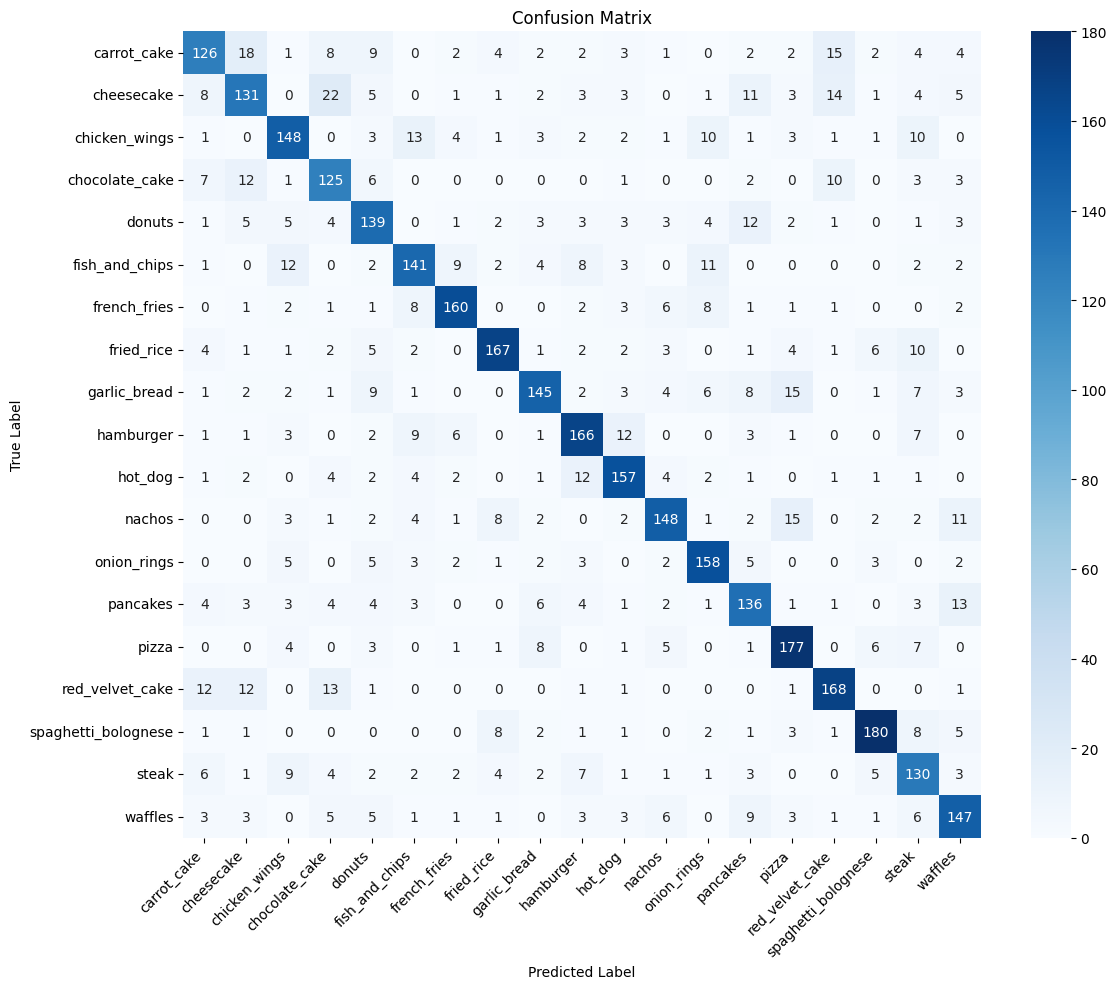

In [137]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Get predictions from the test set
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model_tl.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=1))  # class with highest probability
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Compute and plot the confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,         # show numbers in each cell
    fmt='d',            # format as integers
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [138]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4  # 4 decimal places
)
print(report)

                     precision    recall  f1-score   support

        carrot_cake     0.7119    0.6146    0.6597       205
         cheesecake     0.6788    0.6093    0.6422       215
      chicken_wings     0.7437    0.7255    0.7345       204
     chocolate_cake     0.6443    0.7353    0.6868       170
             donuts     0.6780    0.7240    0.7003       192
     fish_and_chips     0.7382    0.7157    0.7268       197
       french_fries     0.8333    0.8122    0.8226       197
         fried_rice     0.8350    0.7877    0.8107       212
       garlic_bread     0.7880    0.6905    0.7360       210
          hamburger     0.7511    0.7830    0.7667       212
            hot_dog     0.7772    0.8051    0.7909       195
             nachos     0.7957    0.7255    0.7590       204
        onion_rings     0.7707    0.8272    0.7980       191
           pancakes     0.6834    0.7196    0.7010       189
              pizza     0.7662    0.8271    0.7955       214
    red_velvet_cake    

In [139]:
# Only do this for your FINAL chosen model
test_loss, test_accuracy = model_tl.evaluate(test_ds, verbose=1)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# Then get per-class metrics
y_true = []
y_pred = []
for images, labels in test_ds:
    preds = model_tl.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - accuracy: 0.7482 - loss: 0.8618
Test Accuracy: 0.7482
Test Loss: 0.8618
                     precision    recall  f1-score   support

        carrot_cake       0.72      0.61      0.66       205
         cheesecake       0.69      0.62      0.65       214
      chicken_wings       0.74      0.74      0.74       201
     chocolate_cake       0.66      0.73      0.69       177
             donuts       0.69      0.72      0.71       195
     fish_and_chips       0.75      0.71      0.73       198
       french_fries       0.83      0.81      0.82       199
         fried_rice       0.83      0.80      0.82       212
       garlic_bread       0.79      0.68      0.73       208
          hamburger       0.76      0.79      0.77       210
            hot_dog       0.77      0.81      0.79       193
             nachos       0.79      0.73      0.76       203
        onion_rings       0.77      0.82      0.79       192
           pancakes       0.6

# Final Test

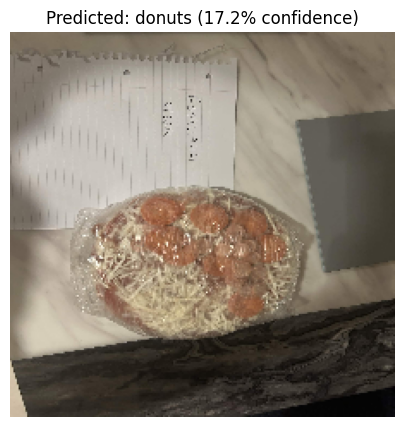

All predictions:
  donuts: 17.16%
  cheesecake: 16.90%
  fried_rice: 11.36%
  garlic_bread: 10.31%
  hot_dog: 7.39%
  carrot_cake: 6.56%
  french_fries: 5.10%
  red_velvet_cake: 4.16%
  chocolate_cake: 3.98%
  pancakes: 3.74%
  hamburger: 3.02%
  pizza: 2.82%
  waffles: 1.77%
  onion_rings: 1.37%
  nachos: 1.33%
  fish_and_chips: 1.03%
  steak: 1.00%
  spaghetti_bolognese: 0.80%
  chicken_wings: 0.22%

./test-photos/pizza.jpg: Predicted 'donuts' with 17.2% confidence



In [142]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image  # or use keras.utils.load_img

def predict_photo(image_path, model, class_names, image_size=(224, 224)):
    # Load and resize the image
    img = keras.utils.load_img(image_path, target_size=image_size)
    img_array = keras.utils.img_to_array(img)          # shape: (H, W, 3)
    img_array = np.expand_dims(img_array, axis=0)      # shape: (1, H, W, 3) — add batch dimension
    
    # Predict
    predictions = model.predict(img_array, verbose=0)
    predicted_class = class_names[np.argmax(predictions[0])]
    confidence = np.max(predictions[0])
    
    # Show the image and result
    plt.figure(figsize=(6, 5))
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class} ({confidence:.1%} confidence)")
    plt.axis('off')
    plt.show()
    
    # Show all class probabilities
    print("All predictions:")
    sorted_indices = np.argsort(predictions[0])[::-1]  # highest first
    for i in sorted_indices:
        print(f"  {class_names[i]}: {predictions[0][i]:.2%}")
    
    return predicted_class, confidence

# Test each of your 4 photos
photo_paths = [
    './test-photos/pizza.jpg'
]

for path in photo_paths:
    predicted, confidence = predict_photo(path, model, class_names)
    print(f"\n{path}: Predicted '{predicted}' with {confidence:.1%} confidence\n")